In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
from src.data_preparation import transform_data,prepare_train_test_data,train_logistic_regression,evaluate_model,drop_unused_columns
from src.data_processing import scale_numerical_features
from src.plots import plot_confusion_matrix, plot_confusion_matrices

In [2]:
fraud_df = pd.read_csv("../data/interim/eda_fraud_df.csv")
credit_df = pd.read_csv("../data/interim/eda_credit_df.csv")

In [3]:
columns_to_drop = [
    "user_id",
    "device_id",
    "ip_address",
    "signup_time",
    "purchase_time",
    "day_of_week"
]

fraud_df = drop_unused_columns(
    fraud_df,
    columns_to_drop
)

Dropped columns: ['user_id', 'device_id', 'ip_address', 'signup_time', 'purchase_time', 'day_of_week']


# Model Building and Training
## Data Preparation
### For Fraud Data

In [4]:
numerical_cols = [
    "purchase_value",
    "age"
]
categorical_cols = [
    "source",
    "browser",
    "sex"
]
fraud_df, scaler = transform_data(
    fraud_df,
    numerical_cols,
    categorical_cols
)

In [5]:
X_train_fraud, X_test_fraud, y_train_fraud, y_test_fraud = (
    prepare_train_test_data(
        fraud_df,
        target_col="class"
    )
)

Training set shape: (120889, 14)
Test set shape: (30223, 14)


In [6]:
print(y_train_fraud.value_counts(normalize=True) * 100)
print(y_test_fraud.value_counts(normalize=True) * 100)

class
0    90.635211
1     9.364789
Name: proportion, dtype: float64
class
0    90.63627
1     9.36373
Name: proportion, dtype: float64


### For Credit Card Data

In [7]:
credit_numerical_cols = [
    "Time", "Amount"
]
credit_df, scaler = scale_numerical_features(
    credit_df,
    credit_numerical_cols
)

In [8]:
X_train_cc, X_test_cc, y_train_cc, y_test_cc = (
    prepare_train_test_data(
        credit_df,
        target_col="Class"
    )
)

Training set shape: (226980, 30)
Test set shape: (56746, 30)


### Apply SMOTE

In [9]:
print(X_train_fraud.select_dtypes(exclude=["number"]).columns)

Index([], dtype='object')


In [10]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_fraud_resampled, y_train_fraud_resampled = (
    smote.fit_resample(
        X_train_fraud,
        y_train_fraud
    )
)

In [11]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_cc_resampled, y_train_cc_resampled = (
    smote.fit_resample(
        X_train_cc,
        y_train_cc
    )
)

## Build Baseline Model(Logistic Regression)
### Fraud Dataset Pipeline
#### Train


In [12]:
fraud_lr = train_logistic_regression(
    X_train_fraud_resampled,
    y_train_fraud_resampled
)

#### Evaluate

In [13]:
fraud_lr_results = evaluate_model(
    fraud_lr,
    X_test_fraud,
    y_test_fraud
)

AUC-PR : 0.2480
F1-Score: 0.2690

Confusion Matrix
[[19380  8013]
 [ 1145  1685]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.71      0.81     27393
           1       0.17      0.60      0.27      2830

    accuracy                           0.70     30223
   macro avg       0.56      0.65      0.54     30223
weighted avg       0.87      0.70      0.76     30223



### Credit Card Dataset Pipeline
#### Train

In [16]:
credit_lr = train_logistic_regression(
    X_train_cc_resampled,
    y_train_cc_resampled
)

#### Evaluate

In [17]:
credit_lr_results = evaluate_model(
    credit_lr,
    X_test_cc,
    y_test_cc
)

AUC-PR : 0.6768
F1-Score: 0.1002

Confusion Matrix
[[55172  1479]
 [   12    83]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



### Confusion Matrix

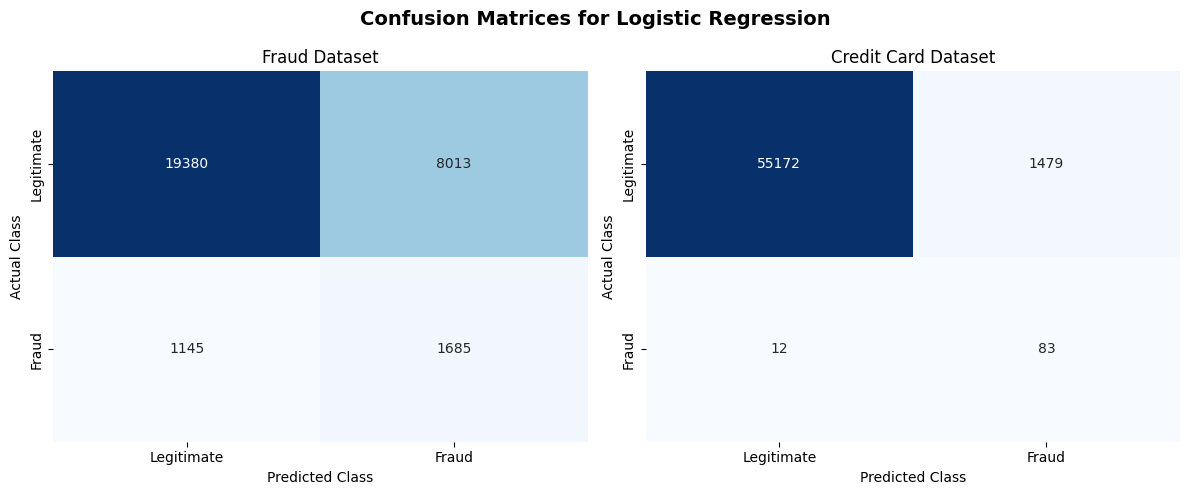

In [18]:
y_pred_fraud = fraud_lr.predict(X_test_fraud)
y_pred_credit = credit_lr.predict(X_test_cc)

plot_confusion_matrices(
    y_test_fraud,
    y_pred_fraud,
    y_test_cc,
    y_pred_credit
)